In [11]:
import torch as pt
import xarray as xr
import pandas as pd
import numpy as np
import torch_dl4ds as dds
from torch_dl4ds import PostUpsamplingNet
from torch_dl4ds import Predictor

In [12]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [13]:
#regridder

import xesmf as xe

hr_grid = uwrf_test[['latitude', 'longitude']] # HR grid definition
lr_grid = nam_test[['latitude', 'longitude']] # LR (NAM) grid definition


regridder = xe.Regridder(lr_grid, hr_grid.coarsen(x=3, y=3, boundary='trim').mean(), method='bilinear')

nam_aligned = regridder(nam_test)

/home/gvaillant1/.conda/envs/pt/lib/python3.11/site-packages/xesmf/frontend.py:75: UserWarning: Variables {'XLAT', 'XLONG'} not found in object but are referred to in the CF attributes.
  lon = ds.cf['longitude']
/home/gvaillant1/.conda/envs/pt/lib/python3.11/site-packages/xesmf/frontend.py:76: UserWarning: Variables {'XLAT', 'XLONG'} not found in object but are referred to in the CF attributes.
  lat = ds.cf['latitude']


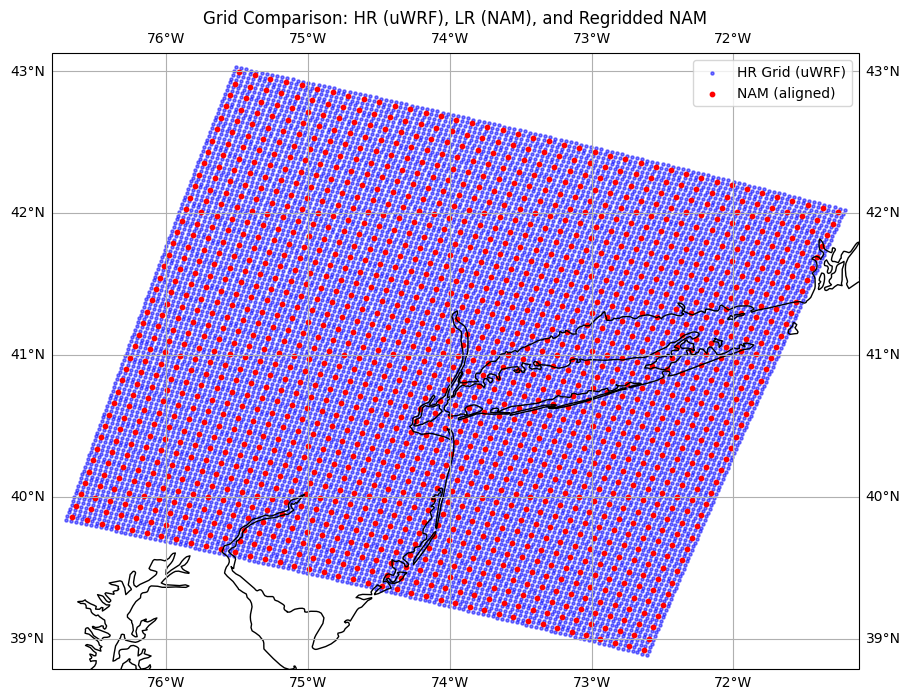

In [14]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# Extract lat/lon (first time slice if time dimension exists)
lat_hr = uwrf_test['latitude'].values
lon_hr = uwrf_test['longitude'].values

lat_lr = nam_test['latitude'].values
lon_lr = nam_test['longitude'].values

lat_aligned = nam_aligned['latitude'].values
lon_aligned = nam_aligned['longitude'].values

# Plot setup
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_hr.min() - 0.1, lon_hr.max() + 0.1, lat_hr.min() - 0.1, lat_hr.max() + 0.1], crs=ccrs.PlateCarree())

ax.coastlines()
ax.gridlines(draw_labels=True)

# Plot HR grid points
ax.scatter(lon_hr, lat_hr, color='blue', s=5, label='HR Grid (uWRF)', alpha=0.5)

# Plot LR (NAM) grid points BEFORE regridding
#ax.scatter(lon_lr, lat_lr, color='red', s=15, label='LR Grid (NAM - original)', marker='x')

# Plot aligned NAM grid points AFTER regridding
ax.scatter(lon_aligned, lat_aligned, color='red', s=10, label='NAM (aligned)', marker='o')

ax.legend(loc='upper right')
plt.title("Grid Comparison: HR (uWRF), LR (NAM), and Regridded NAM")
#plt.title("Grid Comparison: HR (uWRF), LR (NAM)")
plt.show()


In [15]:
nam_aligned

<xarray.Dataset> Size: 26MB
Dimensions:    (time: 578, y: 40, x: 40)
Coordinates:
  * time       (time) datetime64[ns] 5kB 2019-05-04T21:00:00 ... 2019-05-29T1...
    latitude   (y, x) float32 6kB 39.86 39.83 39.81 39.79 ... 42.06 42.03 42.01
    longitude  (y, x) float32 6kB -76.66 -76.56 -76.45 ... -71.48 -71.37 -71.26
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 4MB 295.6 294.9 295.1 ... 288.7 288.6 288.6
    PSFC       (time, y, x) float32 4MB 9.855e+04 9.858e+04 ... 1.003e+05
    U10        (time, y, x) float32 4MB -2.798 -2.674 -2.572 ... 0.04503 -0.1539
    V10        (time, y, x) float32 4MB 0.5568 0.381 0.1814 ... 4.878 5.335
    SWDOWN     (time, y, x) float32 4MB 480.0 462.2 225.2 ... 137.6 115.2 95.77
    PBLH       (time, y, x) float32 4MB 839.7 752.9 791.6 ... 979.7 993.9 899.8
    HGT        (time, y, x) float32 4MB 195.2 193.8 175.1 ... 87.18 67.37 51.89
Attributes:
    regrid_method:  bilinear

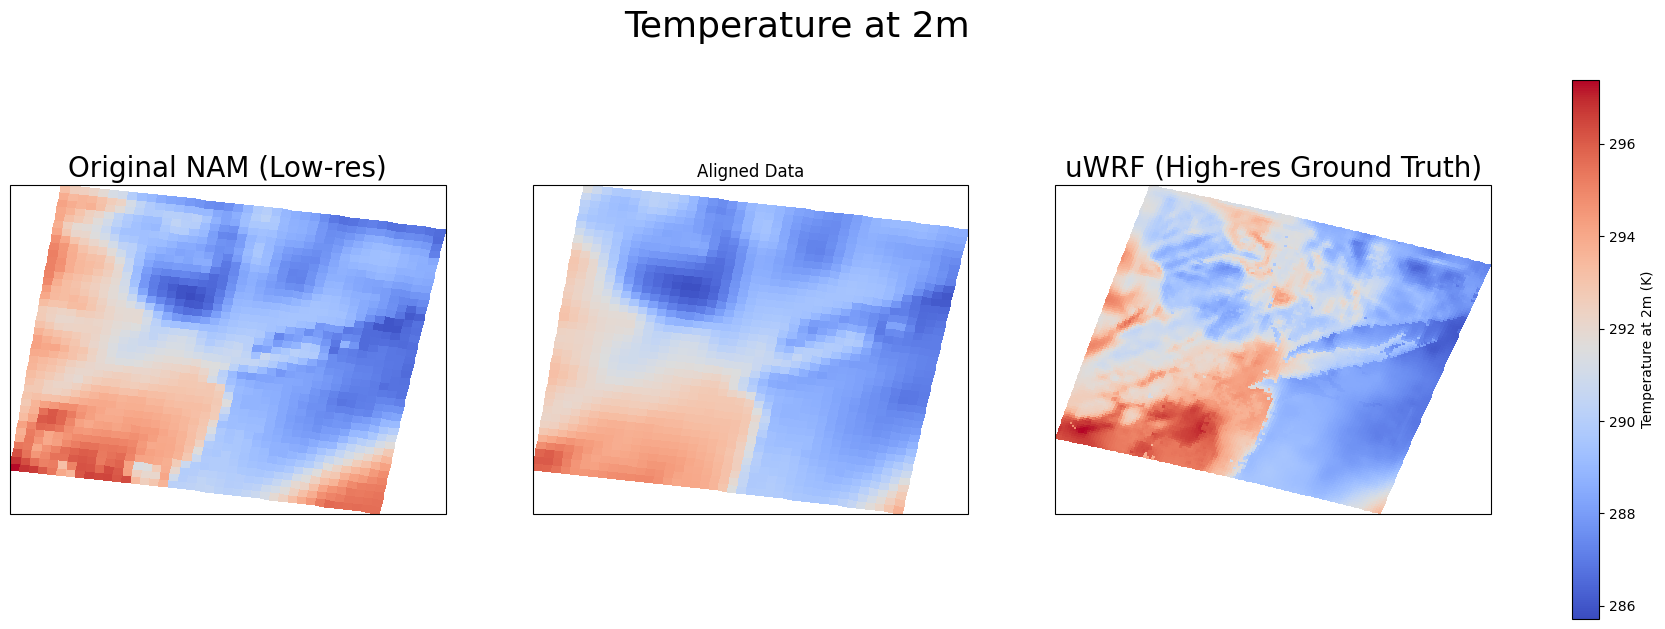

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xarray as xr
import cartopy.feature as cfeature

# Extract data
nam = nam_test.T2  # input
results= nam_aligned.T2
uwrf = uwrf_test.T2  # target


time_idx = -1 # CHANGE

lat_nam = nam.latitude[:,:].values
lon_nam = nam.longitude[:,:].values
t2_nam = nam[time_idx,:,:].values

lat_uwrf = uwrf.latitude[:,:].values
lon_uwrf = uwrf.longitude[:,:].values
t2_uwrf = uwrf[time_idx,:,:].values

# Prediction values — want to be the same resolution as uWRF
t2_pred = results[time_idx, :, :]

# common color limits
vmin = min(t2_nam.min(), t2_uwrf.min())
vmax = max(t2_nam.max(), t2_uwrf.max())

# MAE
#mae = np.mean(np.abs(uwrf - results))
#print(f"MAE: {mae:.2f} K")

# MAPE
#mape = np.mean(np.abs((uwrf - results) / uwrf)) * 100
#print(f"MAPE: {mape:.2f}%")

# RMSE
#rmse = np.sqrt(np.mean((results - uwrf) ** 2))
#print(f"RMSE: {rmse:.2f} K")

fig, axes = plt.subplots(1, 3, figsize=(21, 7), subplot_kw={'projection': ccrs.LambertConformal()})

# Plot NAM
im0 = axes[0].pcolormesh(lon_nam, lat_nam, t2_nam, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.LambertConformal())
axes[0].set_title(f'Original NAM (Low-res)', fontsize=20)
axes[0].coastlines()
#axes[0].gridlines(draw_labels=True)
axes[0].add_feature(cfeature.STATES)

# Plot Prediction
im1 = axes[1].pcolormesh(lon_nam, lat_nam, t2_pred, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.LambertConformal())
axes[1].set_title(f'Aligned Data')
axes[1].coastlines()
#axes[1].gridlines(draw_labels=True)
axes[1].add_feature(cfeature.STATES)

# Plot uWRF
im2 = axes[2].pcolormesh(lon_uwrf, lat_uwrf, t2_uwrf, cmap='coolwarm', vmin=vmin, vmax=vmax, transform=ccrs.LambertConformal())
axes[2].set_title(f'uWRF (High-res Ground Truth)', fontsize=20)
axes[2].coastlines()
#axes[2].gridlines(draw_labels=True)
axes[2].add_feature(cfeature.STATES)

# Single shared colorbar
cbar = fig.colorbar(im2, ax=axes, orientation='vertical', fraction=0.04, pad=0.05)
cbar.set_label('Temperature at 2m (K)')

# Add main title
fig.suptitle(f'Temperature at 2m', fontsize=26)


plt.show()